In [2]:
import os
import numpy as np
import pandas as pd
import glob
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score

In [3]:
########### Part 1
# 1) Data cleaning
##########################
def clean_data(file_path,
               output_dir,
               target_variables,
               special_columns,
               excluded_columns):
    """
    Loads raw data from file_path, converts non-numeric data to numeric,
    deals with missing data, filters timestamps to 1..8, filters target values
    to (0,1), and saves a 'cleaned' CSV. Returns the cleaned DataFrame.
    """
    # 1. Prepare for output
    file_name = os.path.basename(file_path)
    participant_id = file_name.split('.')[0]  # e.g., "01_processed_final"
    cleaned_file_name = f"cleaned_{participant_id}.csv"
    cleaned_file_path = os.path.join(output_dir, cleaned_file_name)

    print(f"--- Cleaning data for {file_name} ---")

    # 2. Load raw data
    df = pd.read_csv(file_path, dtype={col: str for col in target_variables})
    print(f"Initial shape of data: {df.shape}")

    # 3. Convert any cell containing 'F' in the special columns to 0
    for col in special_columns:
        if col in df.columns:
            df[col] = df[col].apply(
                lambda x: 0 if isinstance(x, str) and 'F' in x else
                          (x if isinstance(x, (int, float)) else 0)
            )

    # 4. Convert the target variables to numeric
    for target_variable in target_variables:
        df[target_variable] = df[target_variable].replace({
            "long_happy": 4, "long_sad": 3, "fixation": 2,
            "emotional": 1, "neutral": 0,
            "Emotional": 1, "Neutral": 0
        })
    
    # 5. Keep only rows where all target variables ∈ {0,1}
    df = df[df[target_variables].isin([0, 1]).all(axis=1)]
    if any(df[target_variable].nunique() < 2 for target_variable in target_variables):
        print(f"Warning: Only one label present for some target variables. Skipping {participant_id}.")
        return None

    # 6. Filter to condition time stamps in [1..8]
    df = df[df["condition time stamps"].between(1, 8)]

    # 7. Convert columns (except excluded ones) to numeric, handling missing data
    for col in df.columns:
        if col not in excluded_columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    # Handle missing values: fill NaN with 0
    df.fillna(0, inplace=True)
    
    print(f"Shape after cleaning: {df.shape}")

    # 8. Save the cleaned long-format file
    df.to_csv(cleaned_file_path, index=False)
    print(f"Saved cleaned file to: {cleaned_file_path}")

    return df

# 3) Full pipeline
################################
import os
import glob

def main():
    # Define input and output directories
    input_dir = r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\EEG data\Combined Files\final cleaned individual files\final individuals v2\post baseline correction"
    output_dir = r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\EEG data\Combined Files\ml ready files"
    os.makedirs(output_dir, exist_ok=True)

    target_variables = ["q1_y", "q2_y","q3_y","q4_y"]
    excluded_columns = ["q1_y", "q2_y", "q3_y", "q4_y"]
    special_columns = ["Neutral", "Happy", "Sad", "Angry", "Surprised", "Scared", "Disgusted", "Valence", "Arousal"]

    # Get all CSV files in the input directory
    file_paths = glob.glob(os.path.join(input_dir, "*.csv"))
    
    # Loop through each file and process it
    for file_path in file_paths:
        print(f"Processing {file_path}...")
        
        # 1) CLEAN DATA
        cleaned_df = clean_data(
            file_path=file_path,
            output_dir=output_dir,
            target_variables=target_variables,
            special_columns=special_columns,
            excluded_columns=excluded_columns
        )

if __name__ == "__main__":
    main()

Processing \\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\EEG data\Combined Files\final cleaned individual files\final individuals v2\post baseline correction\corrected_11_processed_final.csv...
--- Cleaning data for corrected_11_processed_final.csv ---
Initial shape of data: (836, 156)
Shape after cleaning: (288, 156)


C:\Users\OLten\AppData\Local\Temp\ipykernel_19960\2606681583.py:36: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[target_variable] = df[target_variable].replace({


Saved cleaned file to: \\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\EEG data\Combined Files\ml ready files\cleaned_corrected_11_processed_final.csv
Processing \\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\EEG data\Combined Files\final cleaned individual files\final individuals v2\post baseline correction\corrected_59_processed_final.csv...
--- Cleaning data for corrected_59_processed_final.csv ---
Initial shape of data: (836, 156)
Shape after cleaning: (288, 156)


C:\Users\OLten\AppData\Local\Temp\ipykernel_19960\2606681583.py:36: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[target_variable] = df[target_variable].replace({


Saved cleaned file to: \\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\EEG data\Combined Files\ml ready files\cleaned_corrected_59_processed_final.csv
Processing \\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\EEG data\Combined Files\final cleaned individual files\final individuals v2\post baseline correction\corrected_05_processed_final.csv...
--- Cleaning data for corrected_05_processed_final.csv ---
Initial shape of data: (836, 156)
Shape after cleaning: (288, 156)


...

Shape after cleaning: (288, 156)
Saved cleaned file to: \\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\EEG data\Combined Files\ml ready files\cleaned_corrected_20_processed_final.csv
Processing \\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\EEG data\Combined Files\final cleaned individual files\final individuals v2\post baseline correction\corrected_03_processed_final.csv...
--- Cleaning data for corrected_03_processed_final.csv ---
Initial shape of data: (836, 156)


C:\Users\OLten\AppData\Local\Temp\ipykernel_19960\2606681583.py:36: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[target_variable] = df[target_variable].replace({


Shape after cleaning: (288, 156)
Saved cleaned file to: \\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\EEG data\Combined Files\ml ready files\cleaned_corrected_03_processed_final.csv
Processing \\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\EEG data\Combined Files\final cleaned individual files\final individuals v2\post baseline correction\corrected_21_processed_final.csv...
--- Cleaning data for corrected_21_processed_final.csv ---
Initial shape of data: (836, 156)
Shape after cleaning: (288, 156)


C:\Users\OLten\AppData\Local\Temp\ipykernel_19960\2606681583.py:36: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[target_variable] = df[target_variable].replace({


Saved cleaned file to: \\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\EEG data\Combined Files\ml ready files\cleaned_corrected_21_processed_final.csv


In [8]:
##################################### Part 2
############### Combine files
"""
Build a single merged CSV from all files in
…\Combined Files\ml ready files
and save it *one level up* in …\Combined Files\ .

Run:  python combine_eeg_files.py
"""

import os, re
import pandas as pd

# ─────── PATHS ───────
# r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\EEG data\Combined Files\ml ready files"
ROOT   = r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\EEG data\Combined Files"
SRC    = os.path.join(ROOT, "ml ready files")          # input location
OUT    = ROOT                                          # where the merged file goes
OUTNAME = "combined_ml_ready_data.csv"

# ─────── MERGE ───────
dfs = []
print("Scanning source folder …")
for file in os.listdir(SRC):
    if file.lower().endswith(".csv"):
        fp = os.path.join(SRC, file)
        df = pd.read_csv(fp)

        # 2‑digit participant ID between first & second "_"
        base = os.path.splitext(file)[0]
        m    = re.search(r"_(\d{2})_", base)
        df["subject_id"] = m.group(1) if m else base
        dfs.append(df)
        print(f"  • {file:<40}  {df.shape}")

all_df = pd.concat(dfs, ignore_index=True)
print(f"\nMerged shape: {all_df.shape}")

# ─────── SAVE ───────
out_path = os.path.join(OUT, OUTNAME)
all_df.to_csv(out_path, index=False)
print(f"Combined file written to: {out_path}")


<>:3: SyntaxWarning: invalid escape sequence '\C'
<>:3: SyntaxWarning: invalid escape sequence '\C'
C:\Users\OLten\AppData\Local\Temp\ipykernel_19960\2191701639.py:3: SyntaxWarning: invalid escape sequence '\C'
  """


Scanning source folder …
  • cleaned_corrected_36_processed_final.csv  (288, 157)
  • cleaned_corrected_45_processed_final.csv  (288, 157)
  • cleaned_corrected_27_processed_final.csv  (288, 157)
  • cleaned_corrected_48_processed_final.csv  (288, 157)
  • cleaned_corrected_53_processed_final.csv  (288, 157)
  • cleaned_corrected_49_processed_final.csv  (288, 157)
  • cleaned_corrected_44_processed_final.csv  (288, 157)
  • cleaned_corrected_31_processed_final.csv  (288, 157)
  • cleaned_corrected_50_processed_final.csv  (288, 157)
  • cleaned_corrected_38_processed_final.csv  (288, 157)
  • cleaned_corrected_43_processed_final.csv  (288, 157)
  • cleaned_corrected_02_processed_final.csv  (288, 157)
  • cleaned_corrected_70_processed_final.csv  (288, 157)
  • cleaned_corrected_42_processed_final.csv  (288, 157)
  • cleaned_corrected_32_processed_final.csv  (288, 157)
  • cleaned_corrected_60_processed_final.csv  (288, 157)
  • cleaned_corrected_58_processed_final.csv  (288, 157)
  • cl

In [ ]:
################## Part 3
# loso_svm.py  ─ runs a linear SVM with LOSO CV
# ----------------------------------------------------------
import os, sys, time
import numpy as np
import pandas as pd
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score

# ─────── 1. Configuration ───────
ROOT = r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\EEG data\Combined Files"
DATA_FILE   = os.path.join(ROOT, "combined_ml_ready_data.csv")
SUMMARY_TXT = os.path.join(ROOT, "loso_svm_summary.txt")

# >>>>>>> Flip this to True for permutation testing <<<<<<<<
PERMUTE_LABELS = False
# ----------------------------------------------------------

# (optional CLI override ↑—uncomment if you like)
# import argparse
# ap = argparse.ArgumentParser()
# ap.add_argument("--perm", action="store_true", help="permute labels")
# PERMUTE_LABELS = ap.parse_args().perm or PERMUTE_LABELS
# ----------------------------------------------------------

rng = np.random.default_rng(seed=42)

# ─────── 2. Load data ───────
df = pd.read_csv(DATA_FILE)
print(f"Loaded: {DATA_FILE}  ➜  {df.shape}")

exclude = {"q1_y", "q2_y", "q3_y", "q4_y","stimID",
           "condition time stamps", "Time (s)"}
feat_cols = [c for c in df.columns if c not in exclude]

X       = df[feat_cols].fillna(0)
y       = df["q1_y"]
groups  = df["subject_id"]

# ─────── 3. LOSO CV ───────
logo = LeaveOneGroupOut()
accs, f1s = [], []

print(f"\nStarting LOSO | permute_labels = {PERMUTE_LABELS}\n")

for fold, (tri, tei) in enumerate(logo.split(X, y, groups), 1):
    test_subj = groups.iloc[tei[0]]
    X_train, X_test = X.iloc[tri], X.iloc[tei]
    y_train, y_test = y.iloc[tri], y.iloc[tei]

    # permutation option
    if PERMUTE_LABELS:
        y_train = pd.Series(rng.permutation(y_train.values),
                            index=y_train.index, name="q1_y")
        y_test  = pd.Series(rng.permutation(y_test.values),
                            index=y_test.index, name="q1_y")

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    clf = SVC(kernel="linear", random_state=42)
    clf.fit(X_train, y_train)
    pred = clf.predict(X_test)

    acc = accuracy_score(y_test, pred)
    f1  = f1_score(y_test, pred, average="weighted")
    accs.append(acc); f1s.append(f1)

    print(f"Fold {fold:02d} | left‑out {test_subj} | Acc {acc:.3f} | F1 {f1:.3f}")
    sys.stdout.flush(); time.sleep(0.05)

# ─────── 4. Summary ───────
acc_mean, acc_sd = np.mean(accs), np.std(accs)
f1_mean,  f1_sd  = np.mean(f1s), np.std(f1s)

summary = (f"LOSO  (perm={PERMUTE_LABELS})\n"
           f"Accuracy : {acc_mean:.3f} ± {acc_sd:.3f}\n"
           f"F1‑weight: {f1_mean:.3f} ± {f1_sd:.3f}\n")

print("\n────────── Overall ──────────\n" + summary)
with open(SUMMARY_TXT, "a") as f:
    f.write(summary + "\n")
print(f"Summary appended to {SUMMARY_TXT}")



Loaded: \\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\EEG data\Combined Files\combined_ml_ready_data.csv  ➜  (19858, 157)

Starting LOSO | permute_labels = False

Fold 01 | left‑out 1 | Acc 0.503 | F1 0.503


In [39]:
# ######################### Cross subject Prediction ##############
# import os
# import numpy as np
# import pandas as pd
# from sklearn.model_selection import train_test_split
# from sklearn.svm import SVC
# from sklearn.preprocessing import StandardScaler
# from sklearn.metrics import accuracy_score, f1_score

# # Configuration
# num_trials = 50  # Number of iterations for both real and permuted tests
# permute_y = True  # Change to True for permutation testing

# # Determine report type
# if permute_y:
#     report_type = "permutation_reports"
#     permutation_label = "permutation"
# else:
#     report_type = "classification_reports"
#     permutation_label = "original"

# # Store evaluation metrics
# evaluation_metrics = []

# # Folder path
# folder_path = r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\EEG data\Combined Files\temp_test"

# # Find all CSV files that start with "wide"
# csv_files = [f for f in os.listdir(folder_path) if f.startswith("wide") and f.endswith(".csv")]

# # Print each file name and shape
# print("Files being combined:")
# df_list = []
# for i, file in enumerate(csv_files):
#     file_path = os.path.join(folder_path, file)
#     df_temp = pd.read_csv(file_path)
#     print(f"{file}: {df_temp.shape}")
    
#     # Append all files but keep the first row only from the first file
#     if i == 0:
#         df_list.append(df_temp)
#     else:
#         df_list.append(df_temp.iloc[1:])  # Skip first row from subsequent files

# # Combine all files by stacking rows (keeping the same column structure)
# df = pd.concat(df_list, ignore_index=True, sort=False)

# # Save the combined DataFrame to a new file
# combined_file_path = os.path.join(folder_path, "combined_wide_data.csv")
# df.to_csv(combined_file_path, index=False)
# print(f"Combined file saved to: {combined_file_path}")

# # Separate features and target variable
# X = df.drop(columns=["q1_y", "q2_y", "q3_y", "q4_y"])  # Features
# y = df["q1_y"]  # Target variable

# # Ensure equal number of samples for both classes
# min_class_size = y.value_counts().min()
# df_balanced = df.groupby("q1_y").sample(n=min_class_size, random_state=42)

# # Re-separate features and target after balancing
# X_balanced = df_balanced.drop(columns=["q1_y", "q2_y", "q3_y", "q4_y"])
# y_balanced = df_balanced["q1_y"]

# # Lists to store accuracy and F1 scores
# accuracies = []
# f1_scores = []

# for i in range(num_trials):
#     # Split data into training and test sets (ensuring equal number of classes in both)
#     X_train, X_test, y_train, y_test = train_test_split(
#         X_balanced, y_balanced, test_size=0.2, stratify=y_balanced
#     )

#     # If permutation is enabled, shuffle the y labels
#     if permute_y:
#         np.random.seed(12)  # Ensure reproducibility
#         y_train = np.random.permutation(y_train.values)
#         y_test = np.random.permutation(y_test.values)

#     # Check for NaN values
#     print("Checking for NaN values in training data...")
#     na_columns = X_train.columns[X_train.isna().any()].tolist()
#     if na_columns:
#         na_counts = X_balanced[na_columns].isna().sum()
#         total_nas = na_counts.sum()
#         total_values = X_balanced.size
#         na_ratio = total_nas / total_values
#         #print(f"Percentage of dataset that is NaN: {na_ratio:.4%}")

#     # If needed, replace NaNs with 0 or column mean
#     X_train.fillna(0, inplace=True)
#     X_test.fillna(0, inplace=True)

#     # Standardize features
#     scaler = StandardScaler()
#     X_train = scaler.fit_transform(X_train)
#     X_test = scaler.transform(X_test)

#     # Train an SVM classifier with a linear kernel
#     svm_model = SVC(kernel="linear", random_state=42)
#     svm_model.fit(X_train, y_train)

#     # Make predictions
#     y_pred = svm_model.predict(X_test)

#     # Evaluate model accuracy
#     accuracy = accuracy_score(y_test, y_pred)
#     f1 = f1_score(y_test, y_pred, average="weighted")
#     print(f"Model Accuracy ({permutation_label}): {accuracy:.4f}")
#     print(f"F1 Score ({permutation_label}): {f1:.4f}")

#      # Store results
#     accuracies.append(accuracy)
#     f1_scores.append(f1)
#     evaluation_metrics.append({"trial": i+1, "accuracy": accuracy, "f1_score": f1})
#     print(f"Trial {i+1}/{num_trials} - Accuracy: {accuracy:.4f}, F1 Score: {f1:.4f}")
    
# # Save evaluation metrics to a CSV file
# metrics_file_path = os.path.join(folder_path, f"{permutation_label}_evaluation_metrics.csv")
# pd.DataFrame(evaluation_metrics).to_csv(metrics_file_path, index=False)
# print(f"Evaluation metrics saved to: {metrics_file_path}")

Files being combined:
wide_1.0.csv: (36, 1197)
wide_11.0.csv: (36, 1197)
wide_15.0.csv: (35, 1197)
wide_17.0.csv: (36, 1197)
wide_20.0.csv: (36, 1197)
wide_22.0.csv: (36, 1197)
wide_24.0.csv: (36, 1197)
wide_3.0.csv: (36, 1197)
wide_30.0.csv: (36, 1197)
wide_33.0.csv: (36, 1197)
wide_34.0.csv: (36, 1197)
wide_37.0.csv: (36, 1197)
wide_39.0.csv: (36, 1197)
wide_43.0.csv: (36, 1197)
wide_45.0.csv: (36, 1197)
wide_46.0.csv: (36, 1197)
wide_47.0.csv: (36, 1197)
wide_49.0.csv: (36, 1197)
wide_5.0.csv: (36, 1197)
wide_50.0.csv: (36, 1197)
wide_51.0.csv: (36, 1197)
wide_52.0.csv: (36, 1197)
wide_53.0.csv: (36, 1197)
wide_54.0.csv: (36, 1197)
wide_55.0.csv: (36, 1197)
wide_57.0.csv: (36, 1197)
wide_6.0.csv: (36, 1197)
wide_61.0.csv: (36, 1197)
wide_62.0.csv: (36, 1197)
wide_63.0.csv: (36, 1197)
wide_67.0.csv: (36, 1197)
Combined file saved to: \\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\EEG data\Combined Files\temp_test\combined_wide_data.csv
Checking for NaN values in 

Model Accuracy (permutation): 0.4931
F1 Score (permutation): 0.4930
Trial 46/50 - Accuracy: 0.4931, F1 Score: 0.4930
Checking for NaN values in training data...
Model Accuracy (permutation): 0.4931
F1 Score (permutation): 0.4930
Trial 47/50 - Accuracy: 0.4931, F1 Score: 0.4930
Checking for NaN values in training data...
Model Accuracy (permutation): 0.4931
F1 Score (permutation): 0.4930
Trial 48/50 - Accuracy: 0.4931, F1 Score: 0.4930
Checking for NaN values in training data...
Model Accuracy (permutation): 0.4931
F1 Score (permutation): 0.4930
Trial 49/50 - Accuracy: 0.4931, F1 Score: 0.4930
Checking for NaN values in training data...
Model Accuracy (permutation): 0.4931
F1 Score (permutation): 0.4930
Trial 50/50 - Accuracy: 0.4931, F1 Score: 0.4930
Evaluation metrics saved to: \\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\EEG data\Combined Files\temp_test\permutation_evaluation_metrics.csv



Descriptive Statistics (Accuracy):
Original  : n=69, M=0.4980, SD=0.0585, SEM=0.0070, 95% CI ±0.0138
Permuted  : n=69, M=0.5002, SD=0.0303, SEM=0.0036, 95% CI ±0.0071

Shapiro-Wilk Test for Normality:
Original Accuracy: W=0.9798, p=0.3264
Permuted Accuracy: W=0.9845, p=0.5527


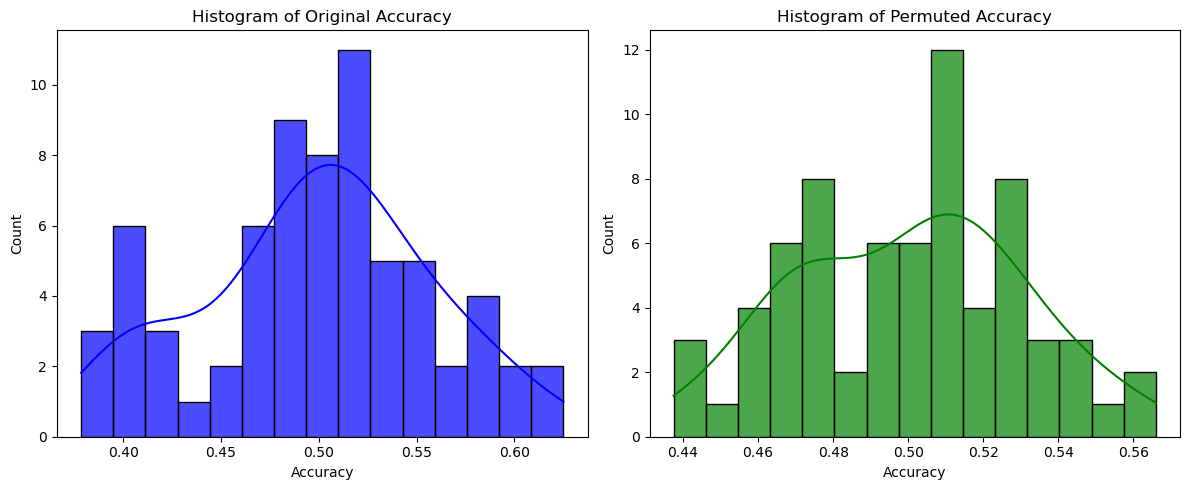

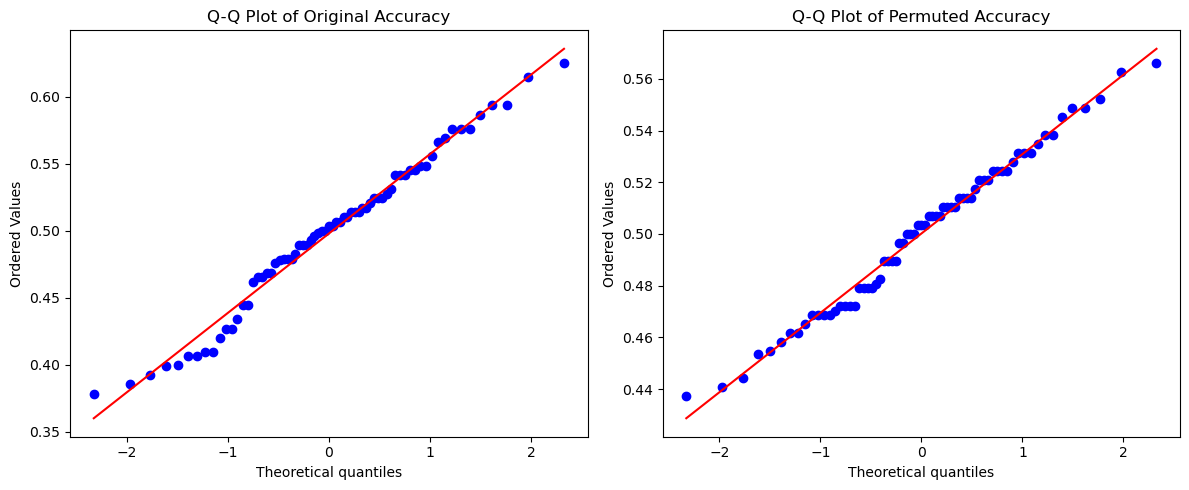


Paired T-Test Results (Accuracy):
t = -0.2598, p = 0.7958
No significant difference in accuracy between real and permuted data.


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# File paths
original_file = r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\EEG data\Combined Files\loso_fold_metrics.csv"
permuted_file = r"\\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\EEG data\Combined Files\loso_fold_metrics_perm.csv"

# Load the data
original_df = pd.read_csv(original_file)
permuted_df = pd.read_csv(permuted_file)

# Extract accuracy scores
original_acc = original_df["acc"].dropna()
permuted_acc = permuted_df["acc"].dropna()

# ==== Descriptive Statistics ====
def describe(data):
    n = len(data)
    mean = np.mean(data)
    sd = np.std(data, ddof=1)
    sem = sd / np.sqrt(n)
    ci95 = 1.96 * sem
    return {"n": n, "M": mean, "SD": sd, "SEM": sem, "95% CI": ci95}

orig_stats = describe(original_acc)
perm_stats = describe(permuted_acc)

print("\nDescriptive Statistics (Accuracy):")
print(f"Original  : n={orig_stats['n']}, M={orig_stats['M']:.4f}, SD={orig_stats['SD']:.4f}, SEM={orig_stats['SEM']:.4f}, 95% CI ±{orig_stats['95% CI']:.4f}")
print(f"Permuted  : n={perm_stats['n']}, M={perm_stats['M']:.4f}, SD={perm_stats['SD']:.4f}, SEM={perm_stats['SEM']:.4f}, 95% CI ±{perm_stats['95% CI']:.4f}")

# ==== Normality Tests (Shapiro-Wilk) ====
print("\nShapiro-Wilk Test for Normality:")
w_orig, p_orig = stats.shapiro(original_acc)
w_perm, p_perm = stats.shapiro(permuted_acc)
print(f"Original Accuracy: W={w_orig:.4f}, p={p_orig:.4f}")
print(f"Permuted Accuracy: W={w_perm:.4f}, p={p_perm:.4f}")

# ==== Figures ====

# Histograms
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(original_acc, kde=True, color='blue', bins=15, alpha=0.7)
plt.title("Histogram of Original Accuracy")
plt.xlabel("Accuracy")
plt.subplot(1, 2, 2)
sns.histplot(permuted_acc, kde=True, color='green', bins=15, alpha=0.7)
plt.title("Histogram of Permuted Accuracy")
plt.xlabel("Accuracy")
plt.tight_layout()
plt.show()

# Q-Q Plots
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
stats.probplot(original_acc, dist="norm", plot=plt)
plt.title("Q-Q Plot of Original Accuracy")
plt.subplot(1, 2, 2)
stats.probplot(permuted_acc, dist="norm", plot=plt)
plt.title("Q-Q Plot of Permuted Accuracy")
plt.tight_layout()
plt.show()

# ==== Paired t-test ====
t_stat, p_value = stats.ttest_rel(original_acc, permuted_acc)

print("\nPaired T-Test Results (Accuracy):")
print(f"t = {t_stat:.4f}, p = {p_value:.4f}")

# Interpretation
alpha = 0.05
if p_value < alpha:
    print("The accuracy for real data is significantly better than permuted data (p < 0.05).")
else:
    print("No significant difference in accuracy between real and permuted data.")


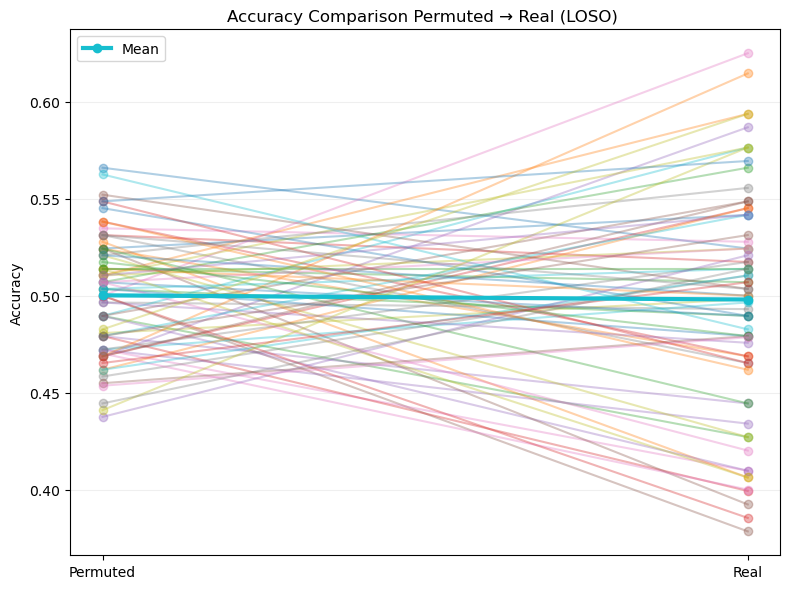

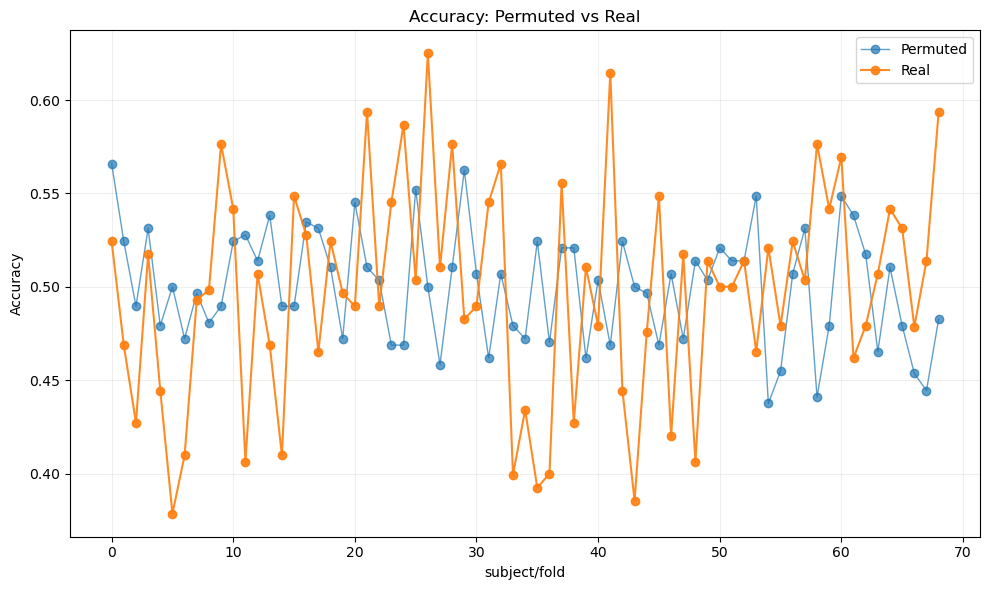

In [7]:
# ==== Direct comparison line plots (Real vs Permuted) ====
import matplotlib.pyplot as plt

# --- 1) Align rows between original and permuted ---
# Try to find a sensible key to merge on
candidate_keys = ["subject_num", "subject", "participant", "fold", "id"]
shared_keys = [k for k in candidate_keys if (k in original_df.columns and k in permuted_df.columns)]

def build_aligned_df(orig_df, perm_df, metric_col="acc"):
    if shared_keys:
        # Keep only needed columns to avoid duplicate metric names
        left = orig_df[shared_keys + [metric_col]].copy()
        right = perm_df[shared_keys + [metric_col]].copy()
        merged = left.merge(right, on=shared_keys, how="inner", suffixes=("_real", "_perm"))
        # Create an id for plotting if none provided
        if not any(k in merged.columns for k in candidate_keys):
            merged["pair_id"] = range(len(merged))
        else:
            # Use the first shared key as an id-like column for plotting
            merged["pair_id"] = merged[shared_keys[0]]
        return merged.rename(columns={f"{metric_col}_real": "acc_real",
                                      f"{metric_col}_perm": "acc_perm"})
    else:
        # Fallback: align by index (assumes same order/length)
        n = min(len(orig_df), len(perm_df))
        df = pd.DataFrame({
            "pair_id": range(n),
            "acc_real": orig_df[metric_col].values[:n],
            "acc_perm": perm_df[metric_col].values[:n],
        })
        return df

aligned = build_aligned_df(original_df, permuted_df, metric_col="acc").dropna(subset=["acc_real","acc_perm"])

# --- 2) Paired slopegraph (each line: permuted -> real for the same pair) ---
plt.figure(figsize=(8, 6))
x_positions = [0, 1]  # 0 = Permuted, 1 = Real
for _, row in aligned.iterrows():
    plt.plot(x_positions, [row["acc_perm"], row["acc_real"]], marker="o", alpha=0.35)

# Add group means
mean_perm = aligned["acc_perm"].mean()
mean_real = aligned["acc_real"].mean()
plt.plot(x_positions, [mean_perm, mean_real], marker="o", linewidth=3, label="Mean")

plt.xticks(x_positions, ["Permuted", "Real"])
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison Permuted → Real (LOSO) ")
plt.legend(loc="best")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

# --- 3) By-pair overlay line plot (x = pair id, two lines for permuted/real) ---
# Sort by pair_id for a cleaner left-to-right progression
aligned_sorted = aligned.sort_values(by="pair_id")

plt.figure(figsize=(10, 6))
plt.plot(aligned_sorted["pair_id"], aligned_sorted["acc_perm"], marker="o", linewidth=1, alpha=0.7, label="Permuted")
plt.plot(aligned_sorted["pair_id"], aligned_sorted["acc_real"], marker="o", linewidth=1.5, alpha=0.9, label="Real")

plt.xlabel("subject/fold")
plt.ylabel("Accuracy")
plt.title("Accuracy: Permuted vs Real")
plt.legend(loc="best")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()
